<a href="https://colab.research.google.com/github/Youssef-Chip/lab1/blob/main/lab3/part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U transformers datasets evaluate accelerate torch torchvision pillow

In [2]:
# Necessary libraries
from transformers import pipeline
from datasets import load_dataset
import evaluate
import time
from PIL import Image

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.14M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/29 [00:00<?, ? examples/s]

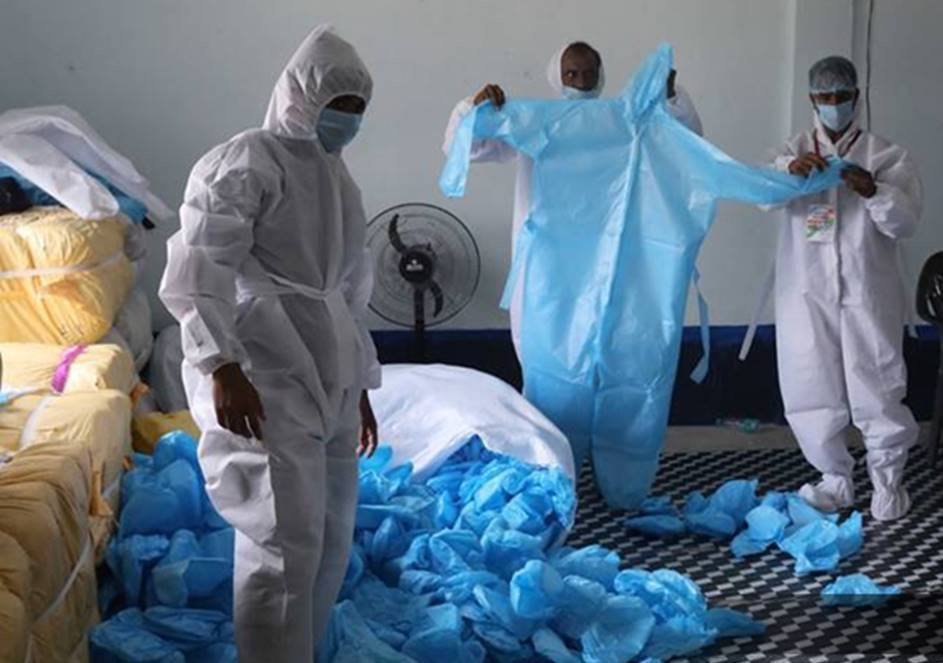

In [3]:
# For the lab, we load the cppe-5 dataset which contains images of medical
# Personal Protective Equipment (PPE) like medical masks, gloves, etc...

# Load only the first 20 images from this dataset
dataset = load_dataset("cppe-5", split="train[:20]")
sample_image = dataset[0]["image"]
sample_image

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.



         IMAGE 1          


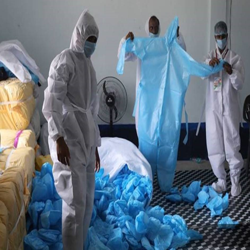

Label: plastic bag          | Confidence: 65.46%
Label: gasmask, respirator, gas helmet | Confidence: 10.60%
Label: sleeping bag         | Confidence: 5.29%
Label: lab coat, laboratory coat | Confidence: 3.55%
Label: shower curtain       | Confidence: 1.47%

         IMAGE 2          


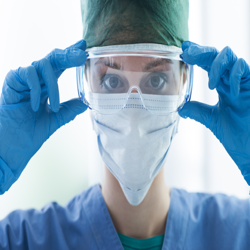

Label: gasmask, respirator, gas helmet | Confidence: 54.75%
Label: lab coat, laboratory coat | Confidence: 33.27%
Label: oxygen mask          | Confidence: 5.66%
Label: mask                 | Confidence: 3.20%
Label: ski mask             | Confidence: 0.51%

         IMAGE 3          


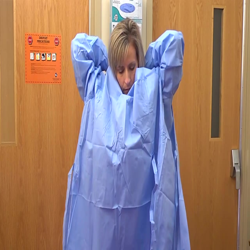

Label: lab coat, laboratory coat | Confidence: 70.99%
Label: apron                | Confidence: 2.01%
Label: shower curtain       | Confidence: 1.82%
Label: stethoscope          | Confidence: 1.76%
Label: poncho               | Confidence: 1.11%

         IMAGE 4          


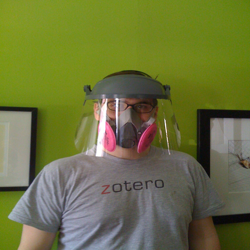

Label: gasmask, respirator, gas helmet | Confidence: 99.76%
Label: oxygen mask          | Confidence: 0.13%
Label: mask                 | Confidence: 0.05%
Label: ski mask             | Confidence: 0.00%
Label: snorkel              | Confidence: 0.00%

         IMAGE 5          


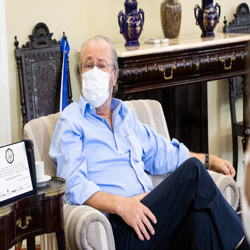

Label: neck brace           | Confidence: 14.31%
Label: oxygen mask          | Confidence: 13.81%
Label: gasmask, respirator, gas helmet | Confidence: 12.63%
Label: mask                 | Confidence: 5.15%
Label: notebook, notebook computer | Confidence: 2.67%


In [5]:

"""
"""
from IPython.display import display

# Initialize the pipeline
print("Downloading and loading the model...")
classifier = pipeline(
  "image-classification",
  model="google/vit-base-patch16-224", # Baseline model trained on ImageNet which contains 1,000 everyday categories
  device=0
)

# Run inferences on the first 5 images
for i in range(5):
  img = dataset[i]["image"]

  # Run the image through the model
  predictions = classifier(img, top_k=5)

  # Visualization
  print(f"\n==============================")
  print(f"         IMAGE {i+1}          ")
  print(f"==============================")
  display(img.resize((250, 250)))

  # Print the top_k labels and confidence scores
  for pred in predictions:
    # Convert to percentage
    print(f"Label: {pred["label"]:<20} | Confidence: {pred["score"]*100:.2f}%")

In [7]:
import time

def measure_latency(model_pipeline, image_list):
  """
  Helper function to measure the latency of the model.
  """
  start_time = time.time()
  for image in image_list:
    _ = model_pipeline(image)
  end_time = time.time()

  # Return the average time per image
  return (end_time - start_time) / len(image_list)

In [11]:
# Initializing the second model
print("Downloading and loading ResNet-50...")
#
classifier_resnet = pipeline(
  "image-classification",
  model="microsoft/resnet-50", # A classic CNN model
  device=0
)

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]


Running latency tests...
ViT Average Latency: 776.72 ms per image
ResNet Average Latency: 221.36 ms per image

  QUALITATIVE COMPARISON (Image 0)


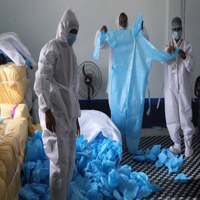


--- ViT Predictions ---
plastic bag          | 65.46%
gasmask, respirator, gas helmet | 10.60%
sleeping bag         | 5.29%
lab coat, laboratory coat | 3.55%
shower curtain       | 1.47%

--- ResNet-50 Predictions ---
lab coat, laboratory coat | 49.60%
plastic bag          | 34.76%
poncho               | 3.44%
abaya                | 1.26%
solar dish, solar collector, solar furnace | 1.10%


In [12]:
"""
Initializing second image classification model to compare with the ViT model
above
"""
# Testing latency and comparing the two models
images_to_test = [dataset[i]["image"] for i in range(20)]
print("\nRunning latency tests...")
vit_latency = measure_latency(classifier, images_to_test)
resnet_latency = measure_latency(classifier_resnet, images_to_test)

print(f"ViT Average Latency: {vit_latency*1000:.2f} ms per image")
print(f"ResNet Average Latency: {resnet_latency*1000:.2f} ms per image")

print("\n==============================================")
print("  QUALITATIVE COMPARISON (Image 0)")
print("==============================================")
test_img = dataset[0]['image']
display(test_img.resize((200, 200)))

print("\n--- ViT Predictions ---")
for pred in classifier(test_img, top_k=5):
    print(f"{pred['label']:<20} | {pred['score']*100:.2f}%")

print("\n--- ResNet-50 Predictions ---")
for pred in classifier_resnet(test_img, top_k=5):
    print(f"{pred['label']:<20} | {pred['score']*100:.2f}%")